Import Libraries

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option('display.max_columns', None)

Load data

In [192]:
import os
print(os.listdir("../data/"))
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

['cleaned_telco_churn.csv', 'Telco_customer_churn.xlsx']


In [193]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)

Index(['customerid', 'count', 'country', 'state', 'city', 'zip_code',
       'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen',
       'partner', 'dependents', 'tenure_months', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charges', 'total_charges', 'churn_label', 'churn_value',
       'churn_score', 'cltv', 'churn_reason'],
      dtype='str')


In [194]:
df = df.drop(columns=['count', 'country', 'state', 'city', 'zip_code',
       'lat_long', 'latitude', 'longitude', 'churn_value'], errors='ignore')

Basic Data Understanding

In [195]:
df.head()

,customerid,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_score,cltv,churn_reason
0,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,86,3239,Competitor made better offer
1,9237-HQITU,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,67,2701,Moved
2,9305-CDSKC,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,86,5372,Moved
3,7892-POOKP,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,84,5003,Moved
4,0280-XJGEX,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,89,5340,Competitor had better devices


In [196]:
df.shape

(7043, 24)

In [197]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         7043 non-null   str    
 1   gender             7043 non-null   str    
 2   senior_citizen     7043 non-null   str    
 3   partner            7043 non-null   str    
 4   dependents         7043 non-null   str    
 5   tenure_months      7043 non-null   int64  
 6   phone_service      7043 non-null   str    
 7   multiple_lines     7043 non-null   str    
 8   internet_service   7043 non-null   str    
 9   online_security    7043 non-null   str    
 10  online_backup      7043 non-null   str    
 11  device_protection  7043 non-null   str    
 12  tech_support       7043 non-null   str    
 13  streaming_tv       7043 non-null   str    
 14  streaming_movies   7043 non-null   str    
 15  contract           7043 non-null   str    
 16  paperless_billing  7043 non-null   

Fixing data types

In [198]:
df["total_charges"] = pd.to_numeric(df['total_charges'], errors='coerce')

In [199]:
categorical_cols = df.select_dtypes(include=['str']).columns
print("Categorical columns: ", categorical_cols)

categorical_cols = categorical_cols.drop('churn_reason', errors='ignore')
print("Categorical columns after dropping 'churn_reason': ", categorical_cols)

for col in categorical_cols:
    df[col] = df[col].astype('category')

Categorical columns:  Index(['customerid', 'gender', 'senior_citizen', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'churn_label', 'churn_reason'],
      dtype='str')
Categorical columns after dropping 'churn_reason':  Index(['customerid', 'gender', 'senior_citizen', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'churn_label'],
      dtype='str')


In [200]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   customerid         7043 non-null   category
 1   gender             7043 non-null   category
 2   senior_citizen     7043 non-null   category
 3   partner            7043 non-null   category
 4   dependents         7043 non-null   category
 5   tenure_months      7043 non-null   int64   
 6   phone_service      7043 non-null   category
 7   multiple_lines     7043 non-null   category
 8   internet_service   7043 non-null   category
 9   online_security    7043 non-null   category
 10  online_backup      7043 non-null   category
 11  device_protection  7043 non-null   category
 12  tech_support       7043 non-null   category
 13  streaming_tv       7043 non-null   category
 14  streaming_movies   7043 non-null   category
 15  contract           7043 non-null   category
 16  paperless_billing

Handling missing values

In [201]:
df.isnull().sum()

customerid              0
gender                  0
senior_citizen          0
partner                 0
dependents              0
tenure_months           0
phone_service           0
multiple_lines          0
internet_service        0
online_security         0
online_backup           0
device_protection       0
tech_support            0
streaming_tv            0
streaming_movies        0
contract                0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges          11
churn_label             0
churn_score             0
cltv                    0
churn_reason         5174
dtype: int64

In [202]:
df['churn_label'].value_counts()

churn_label
No     5174
Yes    1869
Name: count, dtype: int64

In [203]:
''' found out that the missing values in the churn reason column
are all in the 'No Churn' category, so we can safely fill them with 'No Churn' '''

df['churn_reason'] = df['churn_reason'].fillna('No Churn')


In [204]:
df[df['total_charges'].isnull()]

,customerid,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_score,cltv,churn_reason
2234,4472-LVYGI,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,36,2578,No Churn
2438,3115-CZMZD,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,68,5504,No Churn
2568,5709-LVOEQ,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,45,2048,No Churn
2667,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,48,4950,No Churn
2856,1371-DWPAZ,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,30,4740,No Churn
4331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,53,2019,No Churn
4687,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,49,2299,No Churn
5104,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,27,3763,No Churn
5719,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,69,4890,No Churn
6772,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,44,2342,No Churn


In [205]:
# The missing values in total charges are due to new customers who have not yet incurred any charges (tenure = 0), so we can safely fill them with 0 
df['total_charges'] = df['total_charges'].fillna(0)    

In [206]:
df.isnull().sum()

customerid           0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure_months        0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn_label          0
churn_score          0
cltv                 0
churn_reason         0
dtype: int64

In [207]:
df.dropna(inplace=True)

Handling duplicates

In [208]:
df.duplicated().sum()
df[df.duplicated(keep='first')]

,customerid,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_score,cltv,churn_reason


In [209]:
df.to_csv('../data/cleaned_telco_churn.csv', index=False)

Descriptive statistics

In [210]:
df[['tenure_months', 'monthly_charges', 'total_charges']].describe()

,tenure_months,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


Target variable analysis

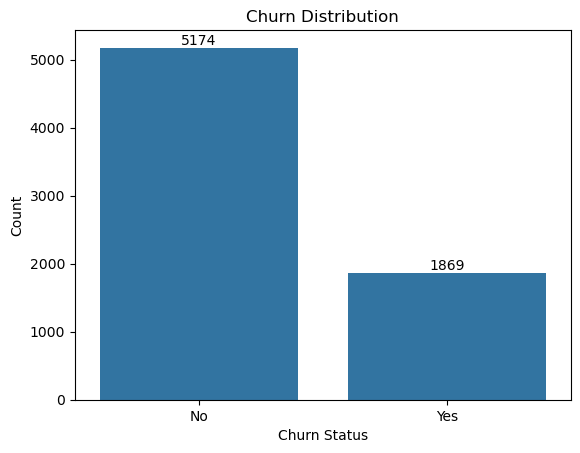

In [211]:
chplt = sns.countplot(x='churn_label', data=df)

for container in chplt.containers:
    chplt.bar_label(container)

plt.title('Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Count')
plt.show()

In [212]:
Churn_percentage = df['churn_label'].value_counts(normalize=True)*100
print(Churn_percentage)

churn_label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


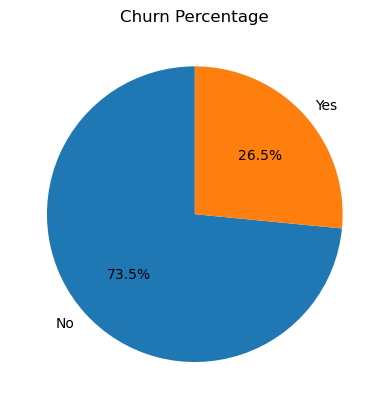

In [213]:
plt.pie(Churn_percentage, labels=Churn_percentage.index, autopct='%1.1f%%', startangle=90)
plt.title('Churn Percentage')
plt.show()

Univariate analysis

In [235]:
Numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print(Numerical_features)

Numerical_features = Numerical_features.drop(['churn_score', 'cltv'], errors='ignore')

Categorical_features = df.select_dtypes(include=['category']).columns
print(Categorical_features)

Categorical_features = Categorical_features.drop(['customerid', 'churn_label'], errors='ignore')
print(Categorical_features)


Index(['tenure_months', 'monthly_charges', 'total_charges', 'churn_score',
       'cltv'],
      dtype='str')
Index(['customerid', 'gender', 'senior_citizen', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'churn_label'],
      dtype='str')
Index(['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method'],
      dtype='str')


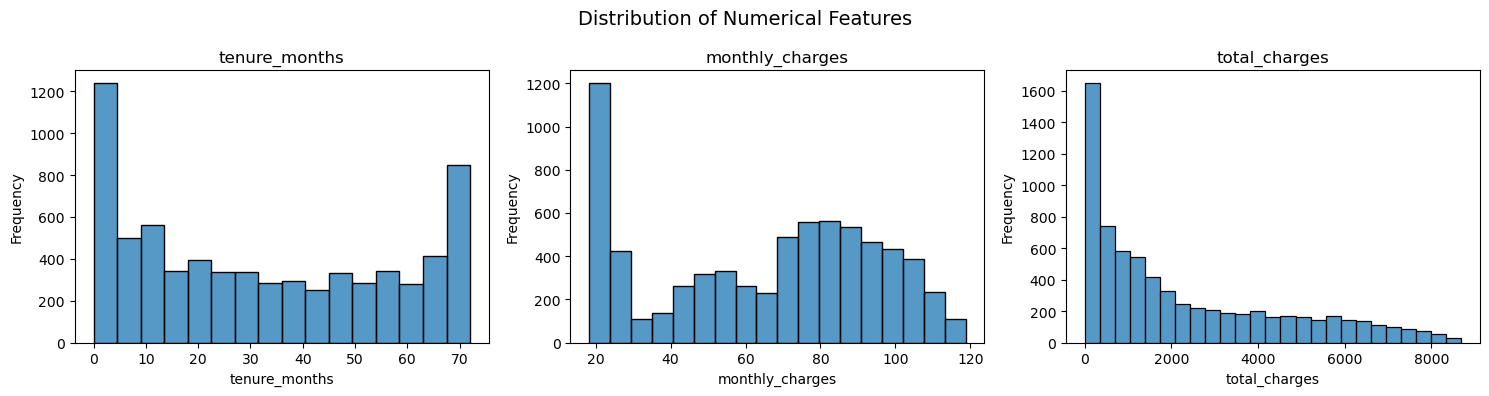

In [238]:
fig, axes = plt.subplots(nrows=1, ncols=len(Numerical_features), figsize=(15, 4))

for i, col in enumerate(Numerical_features):
    sns.histplot(df[col], kde=False, ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{col}')

fig.suptitle('Distribution of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

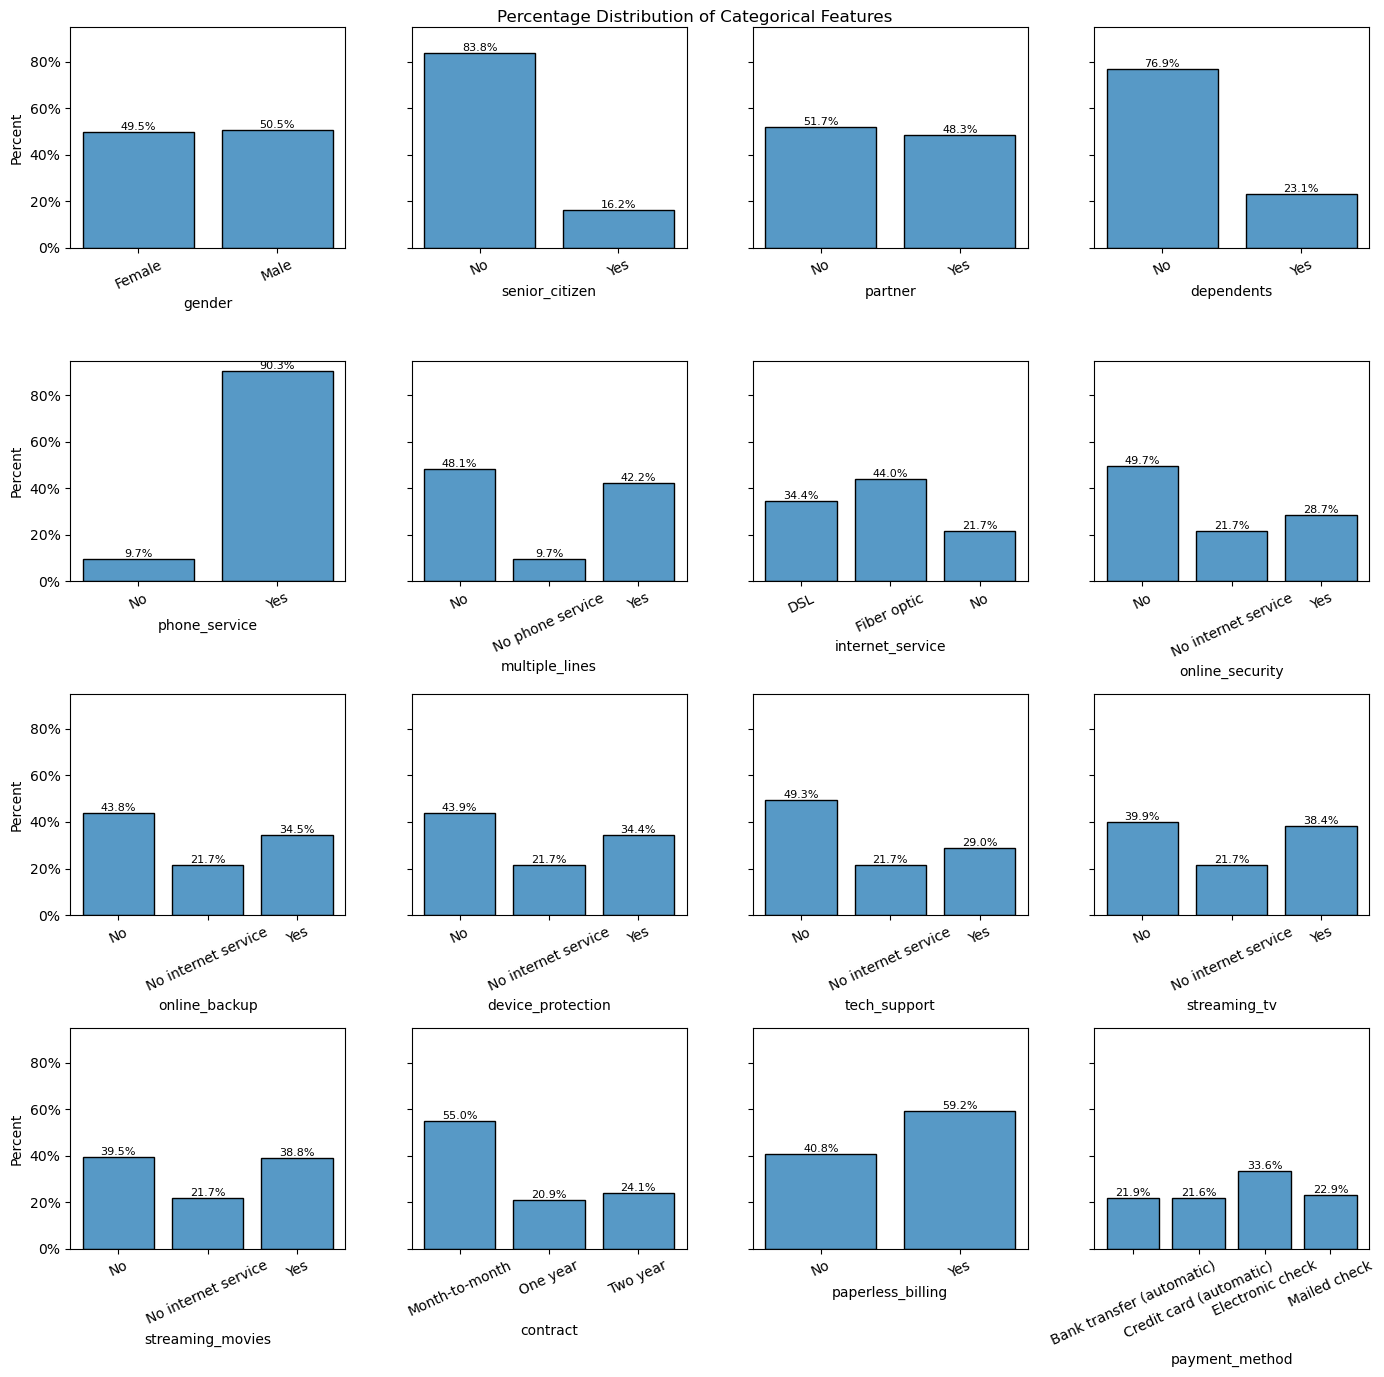

In [245]:
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(14, 14), sharey=True)

for i, feature in enumerate(Categorical_features):
    c = sns.histplot(
        x=feature,
        data=df,
        ax=axes.flat[i],
        stat='percent',
        shrink=0.8
    )

    c.tick_params(axis='x', rotation=25)
    c.yaxis.set_major_formatter(PercentFormatter())

    # Add percentage labels
    for bar in c.containers:
        c.bar_label(
            bar,
            labels=[f'{b.get_height():.1f}%' if b.get_height() > 0 else ''
                    for b in bar],
            label_type='edge',
            fontsize=8
        )

# Remove unused subplots if any
for j in range(len(Categorical_features), 16):
    fig.delaxes(axes.flat[j])

fig.suptitle('Percentage Distribution of Categorical Features')
plt.tight_layout()
plt.show()

Bivariate analysis

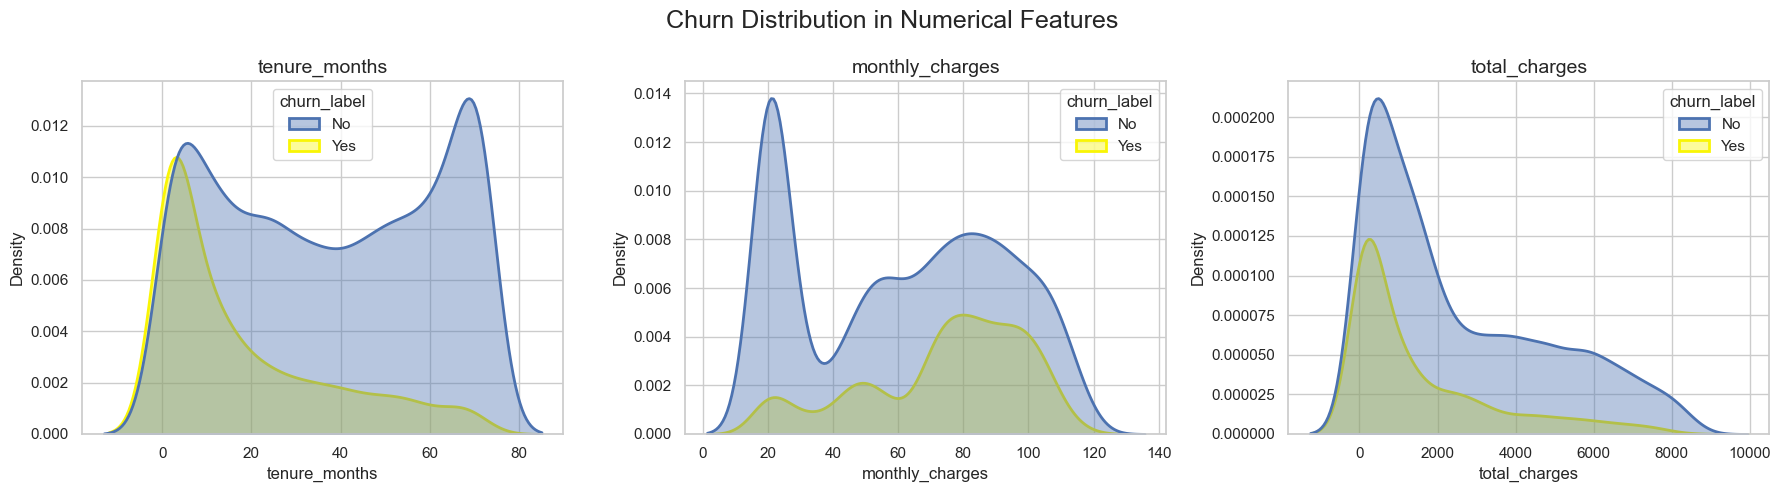

In [250]:
sns.set_theme(style="whitegrid")

palette = ["#4C72B0", "#F9F505"] 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(Numerical_features):
    sns.kdeplot(
        data=df,
        x=feature,
        hue="churn_label",
        fill=True,
        alpha=0.4,
        linewidth=2,
        palette=palette,
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=14)

fig.suptitle("Churn Distribution in Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

Contract Type vs Churn

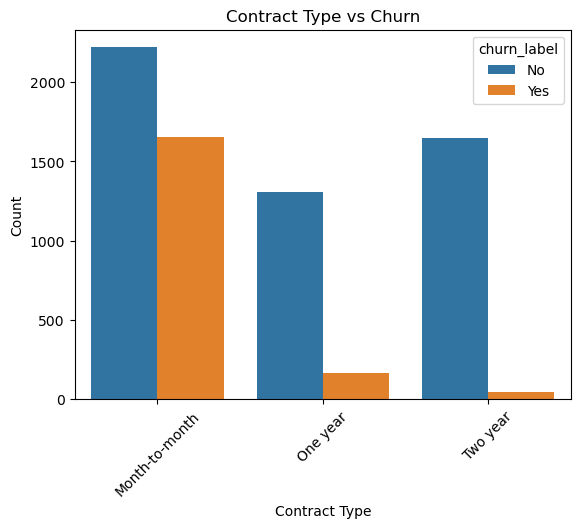

In [217]:
sns.countplot(x='contract', hue='churn_label', data=df)
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [218]:
#Month-to-month has the highest churn and percentage churn compared to other two contract types

Internet Service vs Churn

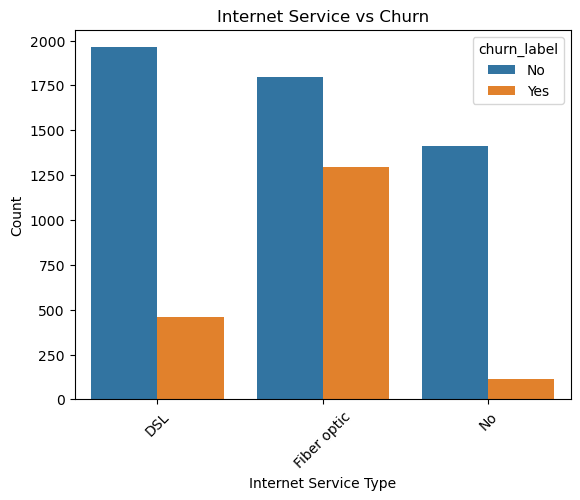

In [219]:
sns.countplot(x='internet_service', hue='churn_label', data=df)
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service Type') 
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [220]:
#Fiber optic has the highest churn and percentage churn compared to other two categories

Payment Method vs Churn

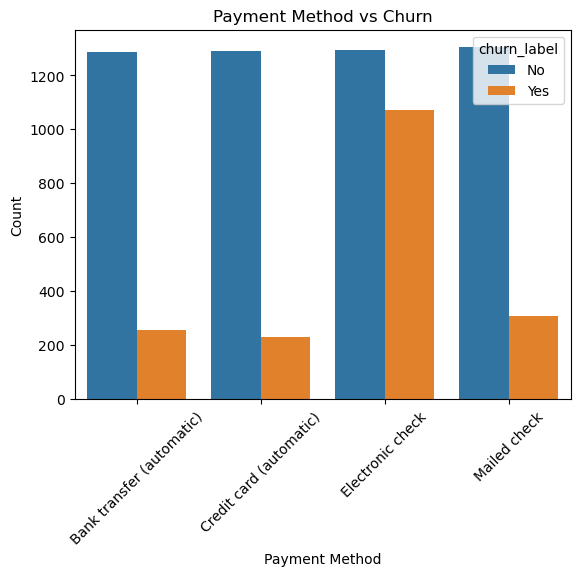

In [221]:
sns.countplot(x='payment_method', hue='churn_label', data=df)
plt.title('Payment Method vs Churn')
plt.xlabel('Payment Method')    
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [222]:
#Electronic check has the highest churn and percentage churn compared to other three categories

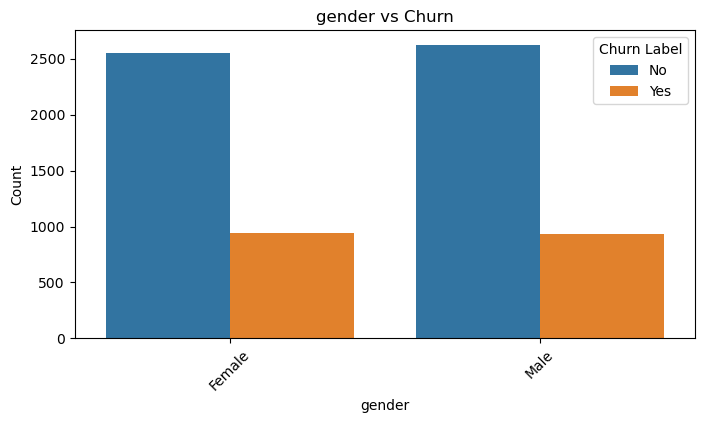

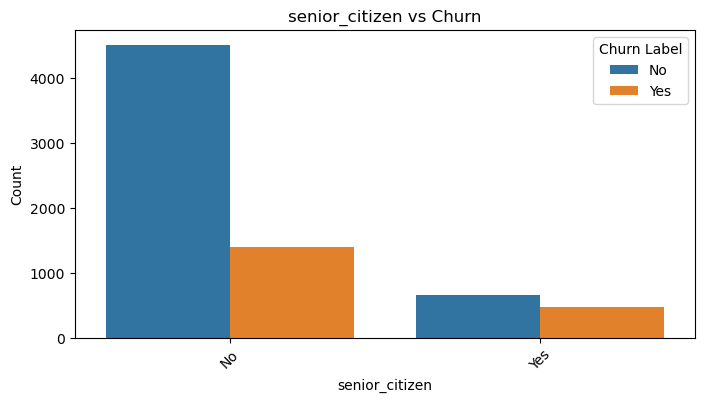

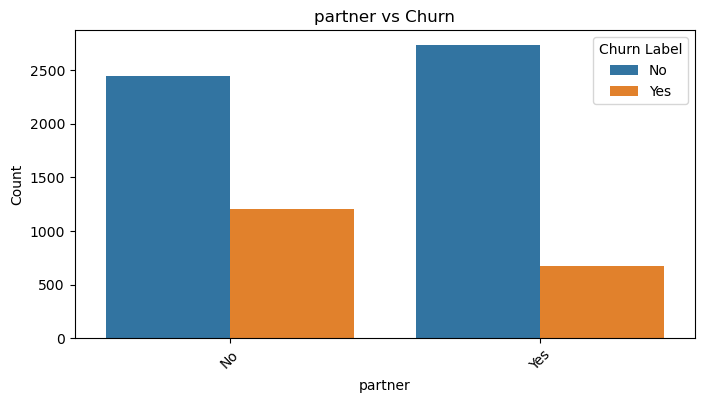

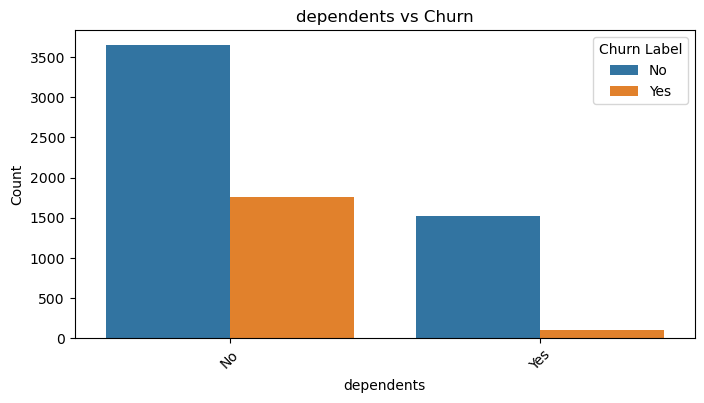

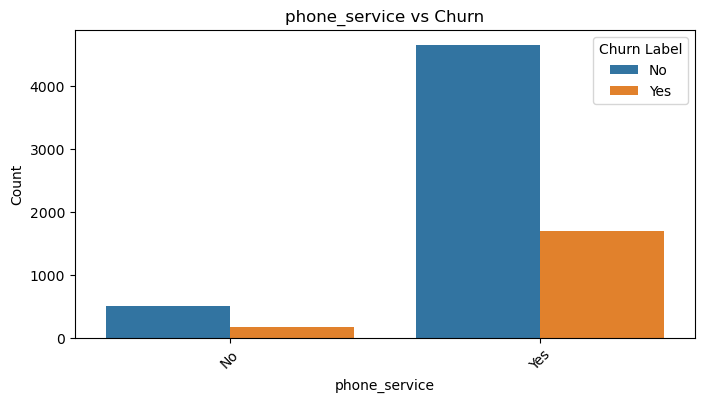

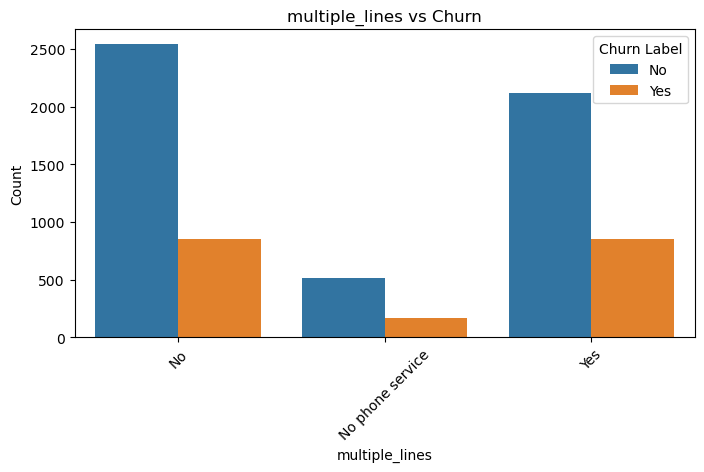

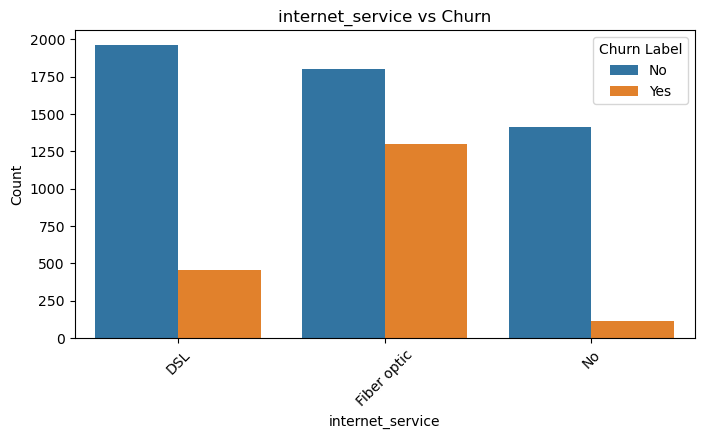

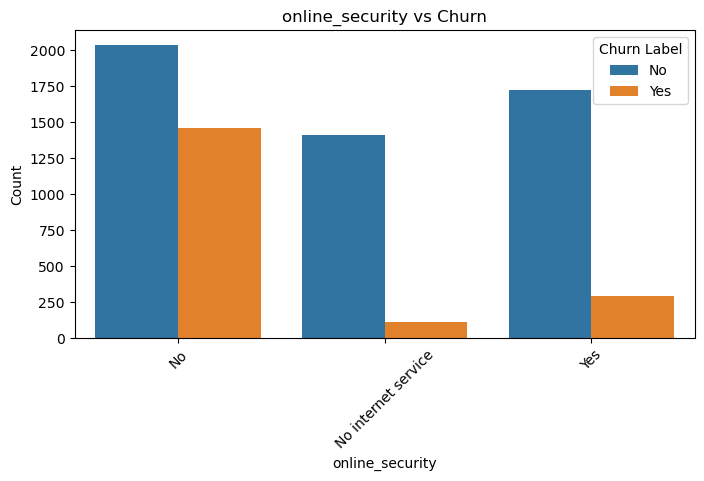

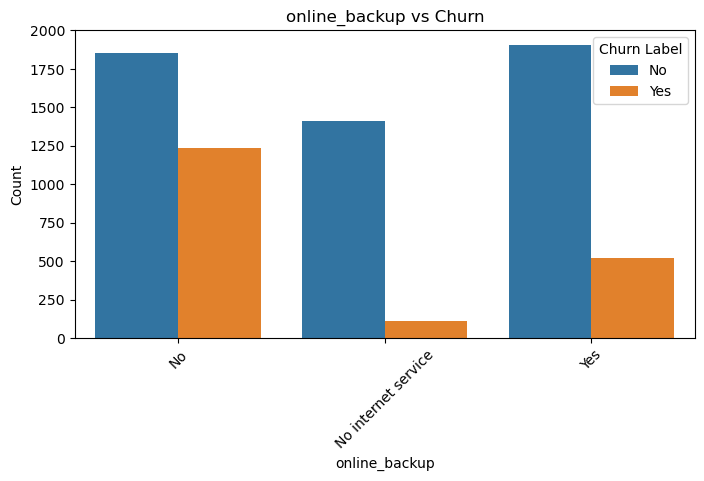

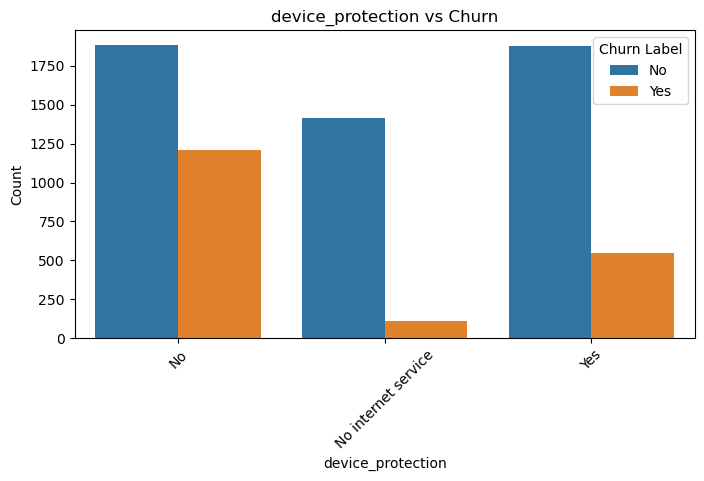

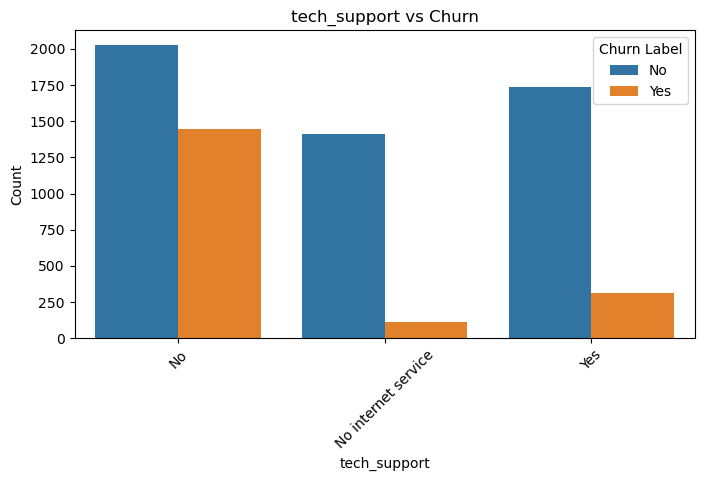

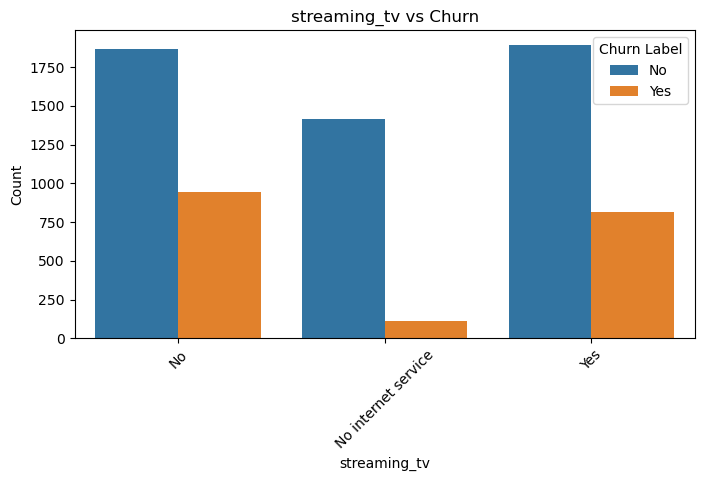

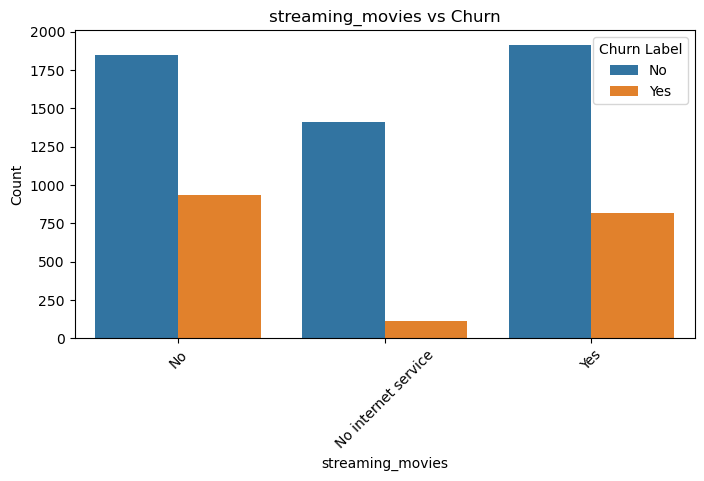

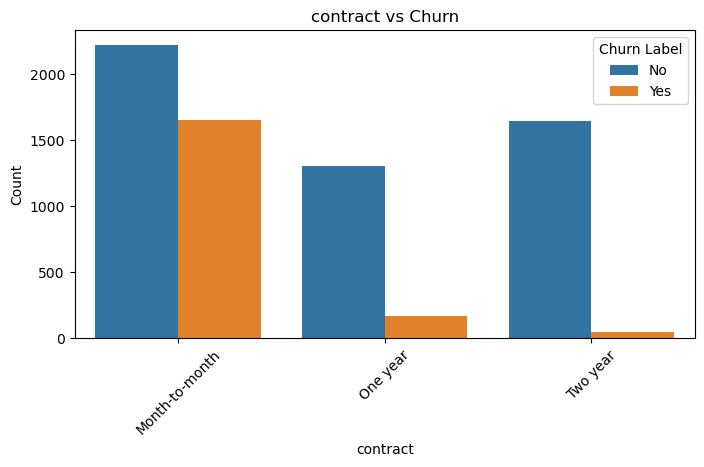

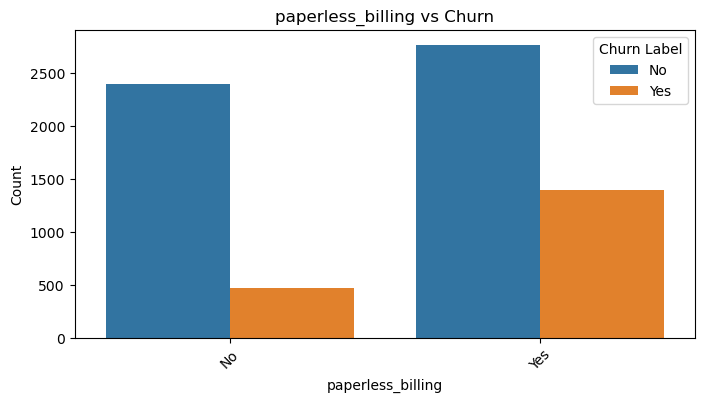

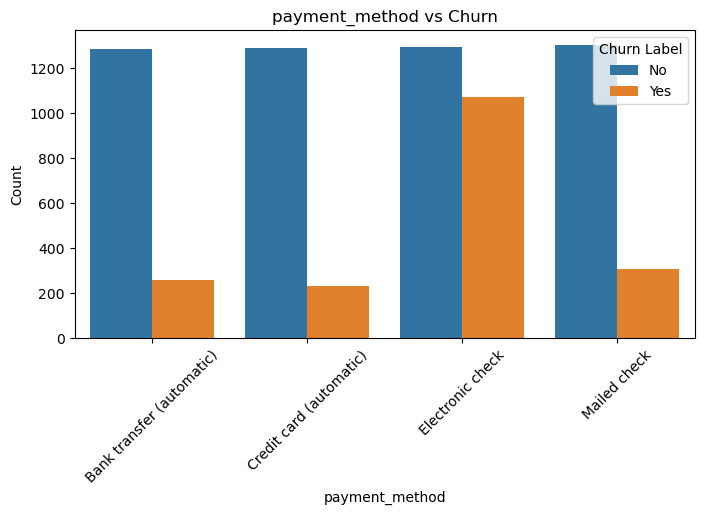

In [247]:
for col in Categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='churn_label', data=df)
    plt.title(f'{col} vs Churn')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Churn Label')
    plt.show()

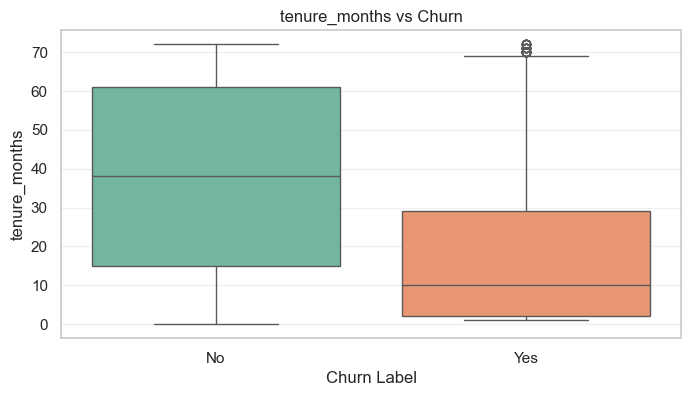

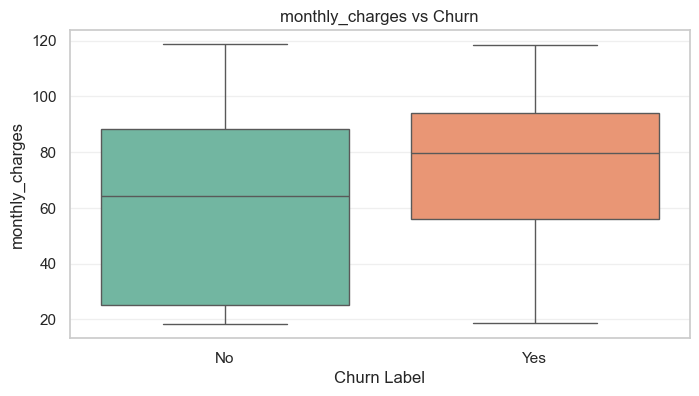

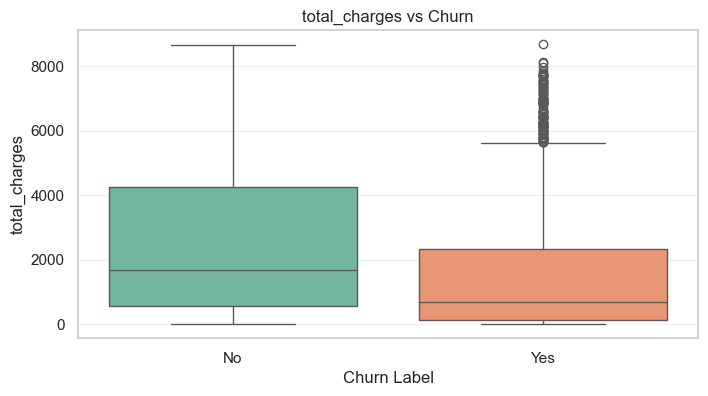

In [254]:
import warnings
warnings.filterwarnings("ignore")

Num_fea = ['tenure_months', 'monthly_charges', 'total_charges']

for col in Num_fea:
    plt.figure(figsize=(8,4))
    
    sns.boxplot(
        x='churn_label',
        y=col,
        data=df,
        palette="Set2"
    )
    
    plt.title(f'{col} vs Churn')
    plt.xlabel('Churn Label')
    plt.ylabel(col)
    plt.grid(axis='y', alpha=0.3)
    
    plt.show()

In [225]:
#Tenure Months: Customers who churned have a lower median tenure compared to those who did not churn, indicating that newer customers are more likely to churn.
#Suggests that customers who have been with the company for a shorter period may be more likely to churn, possibly due to dissatisfaction or unmet expectations.

#Monthly Charges: Customers who churned tend to have higher monthly charges compared to those who did not churn, suggesting that higher costs may be a factor contributing to churn.


Multivariate analysis

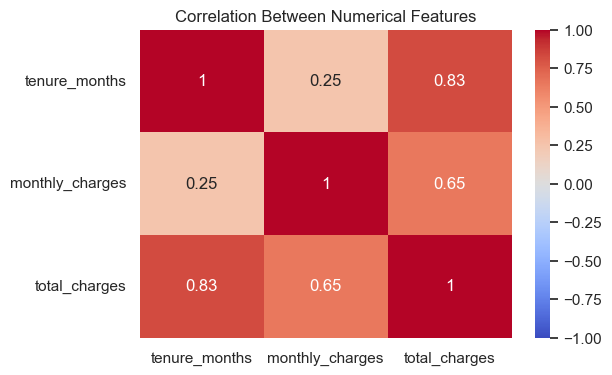

In [263]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[['tenure_months','monthly_charges','total_charges']].corr(),
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Numerical Features")
plt.show()

In [ ]:
#tenure vs total charges has a strong positive correlation, Long-term customers naturally accumulate higher charges
#monthly charges vs total charges has a moderate positive correlation, Higher monthly plans lead to higher lifetime spend
#tenure vs monthly charges has a weak correlation, Pricing is not strongly dependent on customer duration 

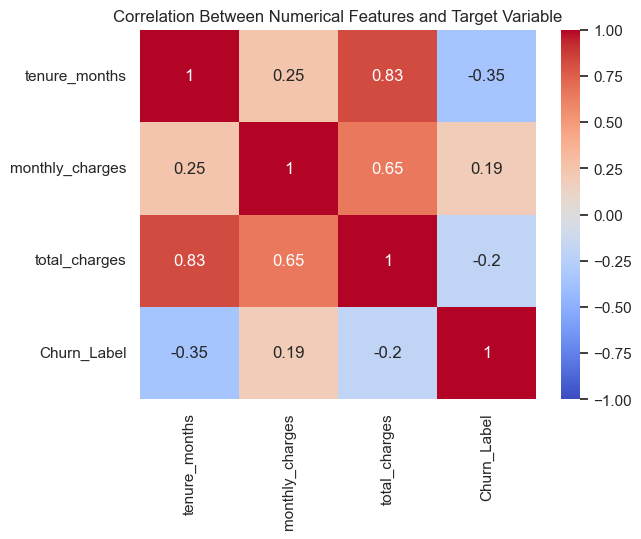

In [270]:
df['Churn_Label'] = df['churn_label'].map({'No':0,'Yes':1})

sns.heatmap(
    df[['tenure_months','monthly_charges','total_charges','Churn_Label']].corr(),
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Numerical Features and Target Variable")
plt.show()

Outlier Detection

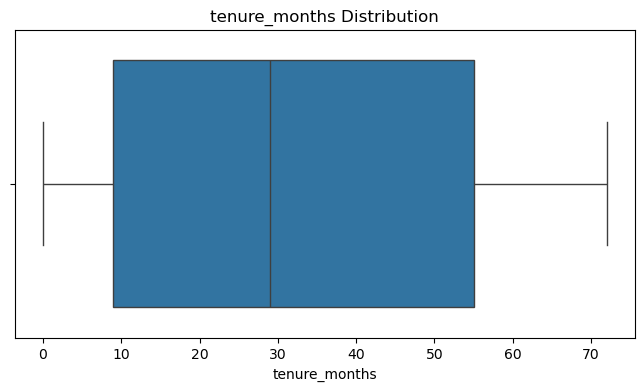

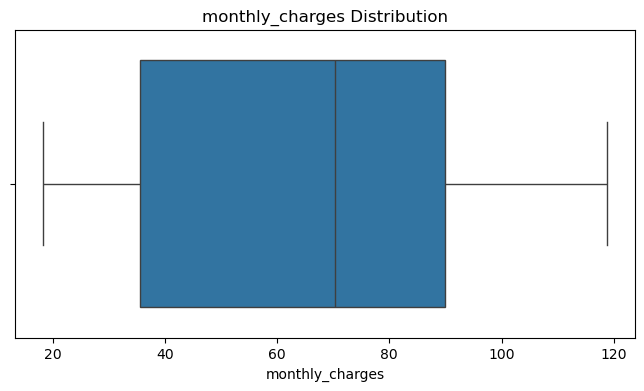

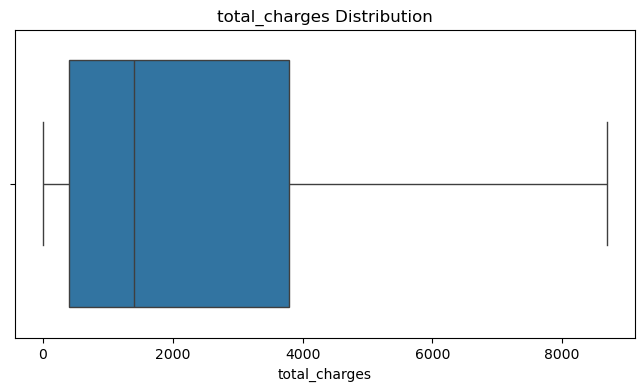

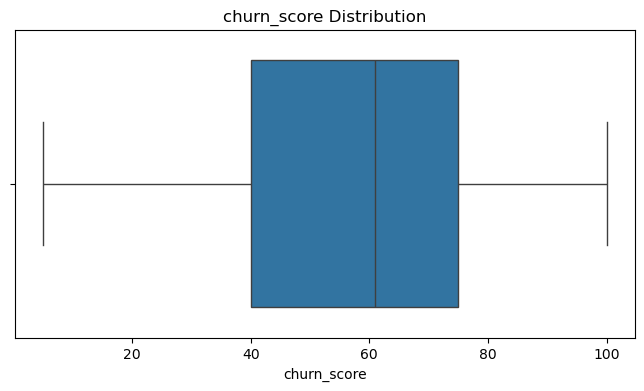

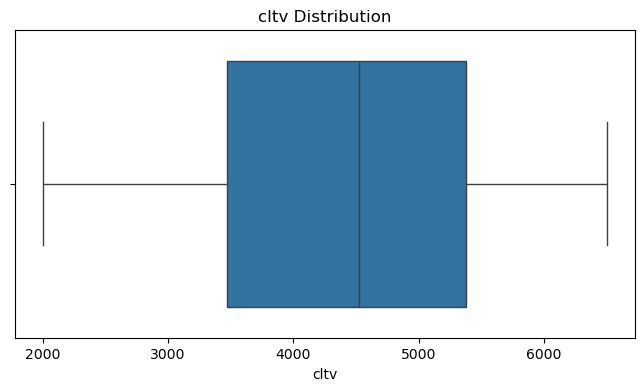

In [229]:

for col in Numerical_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'{col} Distribution')
    plt.show()

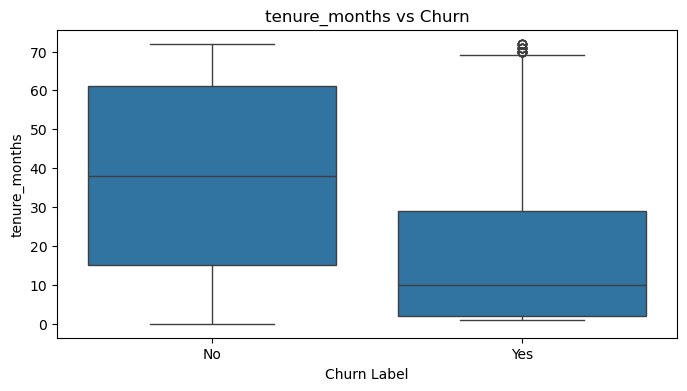

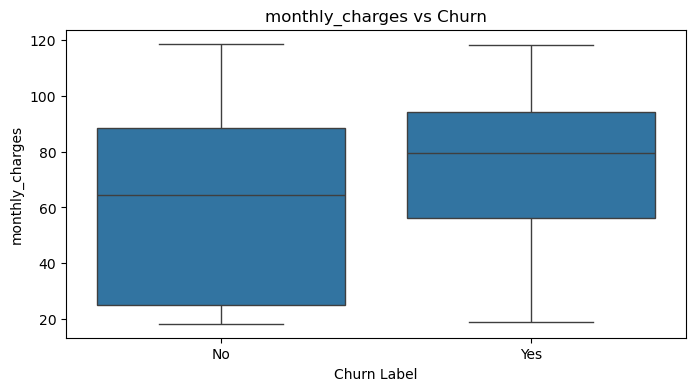

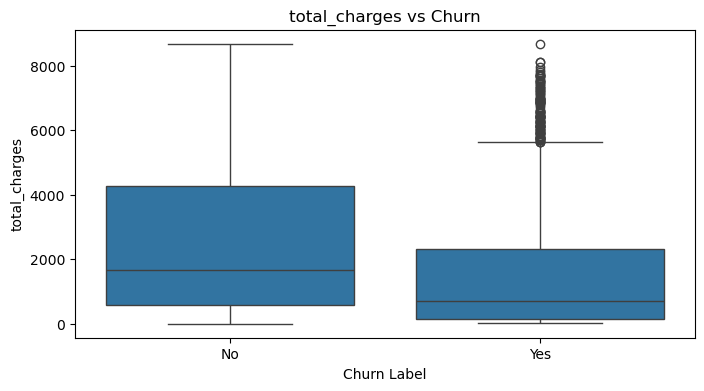

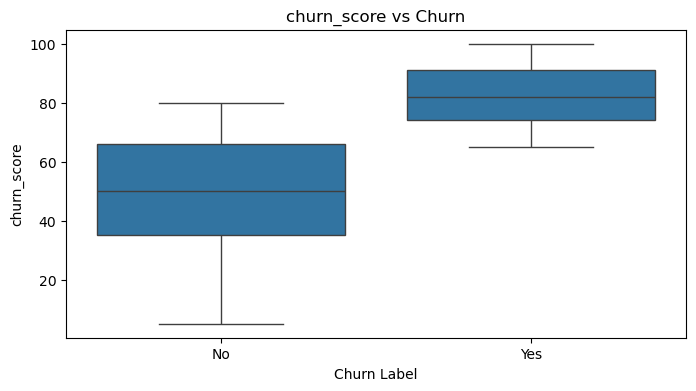

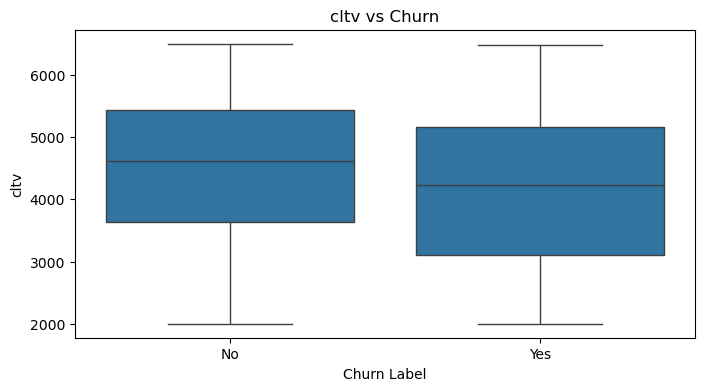

In [230]:
for col in Numerical_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='churn_label', y=col, data=df)
    plt.title(f'{col} vs Churn')
    plt.xlabel('Churn Label')
    plt.ylabel(col)
    plt.show()

In [232]:
#Tenure months has some outliers, indicating churn of customers with very high tenure, which may be due to long-term customers who eventually decide to churn. 

#Total has a considerable number of outliers, which may be due to customers with high total charges who are more likely to churn, possibly due to dissatisfaction with the cost of services.

Business Insights

In [233]:
'''
Churn Distribution
Approximately 27% of customers have churned.

Contract Type
Month-to-month customers exhibit significantly higher churn.

Tenure
Customers with short tenure are more likely to leave.

Monthly Charges
High-paying customers tend to churn more frequently.

Internet Service
Fiber optic users experience relatively higher churn. 

Payment Method
Customers who uses electronic cheques as the payment method relatively tend to churn more.

Customers who do not subscribe to support services, 
specifically Online Security, Online Backup, Device Protection, and Tech Support
exhibit significantly higher churn rates compared to those who do.'''

'\nChurn Distribution\nApproximately 27% of customers have churned.\n\nContract Type\nMonth-to-month customers exhibit significantly higher churn.\n\nTenure\nCustomers with short tenure are more likely to leave.\n\nMonthly Charges\nHigh-paying customers tend to churn more frequently.\n\nInternet Service\nFiber optic users experience relatively higher churn. \n\nPayment Method\nCustomers who uses electronic cheques as the payment method relatively tend to churn more.\n\nCustomers who do not subscribe to support services, \nspecifically Online Security, Online Backup, Device Protection, and Tech Support\nexhibit significantly higher churn rates compared to those who do.'